# Step 7 : Tuning and Stacking

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.tree import DecisionTreeRegressor 
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor 
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix, classification_report

In [2]:
filepath = r'dataset/weekly_btc_2017_2026.csv'
theme_color = ['#36827F','#464D77','#F9DB6D','#F4EDED','#877666'] 

In [3]:
df = pd.read_csv(filepath, index_col= 'Unnamed: 0')
df.index = pd.to_datetime(df.index) 
df.sort_index(ascending = True, inplace=True)

In [4]:
df = df.drop(columns = ['pct_change_1w','pct_change_4w','pct_change_8w'])

In [5]:
df.head(3)

,Sentiment,Open,High,Low,Close,Volume,year,month,quarter,weekno
2017-01-06,0.036157,963.658020,1191.099976,883.943970,902.200989,1762148992,2017,1,1,1
2017-01-13,-0.038909,903.487000,942.723999,755.755981,823.984009,1398173008,2017,1,1,2
2017-01-20,-0.075130,825.142029,917.499023,812.455994,895.026001,819957496,2017,1,1,3


In [6]:
df.index.to_series().rename('date').agg(['min', 'max'])

min   2017-01-06
max   2026-04-17
Name: date, dtype: datetime64[ns]

## Target Column Creation

In [7]:
df['r1'] = df['Close'].pct_change(periods = 1)

In [8]:
# QUANTILE method (Balanced Classes) -
upper_threshold = 0.01
lower_threshold = -0.01

mask = (df['r1'] > upper_threshold) | (df['r1'] < lower_threshold) 

print("Kept:", mask.sum())
print("Dropped neutral:", (~mask).sum())
print("Kept %:", mask.mean())

df = df.loc[mask].copy()
df['label_q'] = (df.loc[mask, 'r1'] > upper_threshold).astype(int) # uptrend is 1 , downtrend is 0

Kept: 417
Dropped neutral: 68
Kept %: 0.8597938144329897


## Feature Engeeneering

In [9]:
EPS = 1e-8

# Compute r1
df['r1'] = df['Close'].pct_change(1) 

# compute lag r1 
for lag in [2,4,8,12]:
    df[f"r1_lag{lag}"] = df['r1'].shift(lag) 

# Compute lag multi-Horizon return then lag 
for k in [2,4,8,12]:
    df[f"r{k}_lag1"] = df["Close"].pct_change(k).shift(1)

# Compute Volatility/momentum on weekly log returns then lag 
for w in [2,4,8,12]:
    df[f"vol_{w}w_lag1"] = df["r1"].rolling(w).std().shift(1)
    df[f"mom_{w}w_lag1"] = df["r1"].rolling(w).mean().shift(1) 

# compute high-low range 
df["hl_range"] = (df["High"] - df["Low"]) / (df["Close"] + EPS)

for w in [2,4,8,12]:
    df[f"hl_range_mean_{w}_lag1"] = df["hl_range"].rolling(w).mean().shift(1)
    df[f"hl_range_std_{w}_lag1"] = df["hl_range"].rolling(w).std().shift(1) 

# ---- Trend ---
for w in [2,4,8,12]:
    ma = df["Close"].rolling(w).mean()
    df[f"close_to_ma_{w}_lag1"] = ((df["Close"] - ma) / (ma + EPS)).shift(1)
    df[f"ma_slope_{w}_lag1"] = ma.diff().shift(1)

# --- Volume ---
df["dollar_volume_lag1"] = (df["Close"] * df["Volume"]).shift(1)
df["volume_change_1_lag1"] = df["Volume"].pct_change().shift(1)

for w in [2,4,8,12]:
    vol_mu = df["Volume"].rolling(w).mean()
    vol_sd = df["Volume"].rolling(w).std()
    
    df[f"vol_ratio_{w}_lag1"] = (df["Volume"] / (vol_mu + EPS)).shift(1)
    df[f"vol_z_{w}_lag1"] = ((df["Volume"] - vol_mu) / (vol_sd + EPS)).shift(1)

# Define RSI function
def rsi_wilder(close: pd.Series, period: int = 14) -> pd.Series:
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = (-delta).clip(lower=0)

    avg_gain = gain.ewm(alpha=1/period, adjust=False, min_periods=period).mean()
    avg_loss = loss.ewm(alpha=1/period, adjust=False, min_periods=period).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

for p in [4,8,12]:
    df[f"RSI_{p}w"] = rsi_wilder(df["Close"], p)
    df[f"RSI_{p}w_lag1"] = df[f"RSI_{p}w"].shift(1)


# sentiment features engineering 
df["sentiment_lag_1"] = df["Sentiment"].shift(1)
df["sentiment_chg_1_lag1"] = df["Sentiment"].diff(1).shift(1)
df["sentiment_chg_2_lag1"] = df["Sentiment"].diff(2).shift(1) 

# rolling sentiment 
for w in [4,8]:
    df[f"s_mean_{w}_lag1"] = df["Sentiment"].rolling(w).mean().shift(1)
    df[f"s_std_{w}_lag1"]  = df["Sentiment"].rolling(w).std().shift(1) 

# extreme sentiment features 
z = (df["Sentiment"] - df["Sentiment"].rolling(8).mean()) / df["Sentiment"].rolling(8).std()
df["sentiment_z8_lag1"] = z.shift(1)

# x momentum features 
df['sentiment_x_momentum_lag1'] = df['sentiment_lag_1'] * df['mom_4w_lag1']
df['rsi_x_sentiment_lag1'] = df['RSI_4w_lag1'] *df['sentiment_lag_1'] 
df['sentiment_x_trend_lag1'] = df['sentiment_lag_1'] * df['close_to_ma_4_lag1']

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 417 entries, 2017-01-13 to 2026-04-17
Data columns (total 72 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Sentiment                  417 non-null    float64
 1   Open                       417 non-null    float64
 2   High                       417 non-null    float64
 3   Low                        417 non-null    float64
 4   Close                      417 non-null    float64
 5   Volume                     417 non-null    int64  
 6   year                       417 non-null    int64  
 7   month                      417 non-null    int64  
 8   quarter                    417 non-null    int64  
 9   weekno                     417 non-null    int64  
 10  r1                         416 non-null    float64
 11  label_q                    417 non-null    int64  
 12  r1_lag2                    414 non-null    float64
 13  r1_lag4                    412 

In [11]:
import numpy as np
import pandas as pd

from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, balanced_accuracy_score

from xgboost import XGBClassifier

In [12]:
# --- 1) Define columns set for different scenario ---
price_cols = [    
    # --- Returns / momentum ---
    'r1_lag2',
    'r1_lag8',
    'r1_lag12',
    'r4_lag1',

    # --- Volatility ---
    'vol_4w_lag1',
    'mom_4w_lag1',
    'vol_12w_lag1',
    'mom_12w_lag1',
    'hl_range_std_4_lag1',
    'hl_range_std_12_lag1',

    # --- Trend ---
    'close_to_ma_4_lag1',
    'ma_slope_4_lag1',
    'close_to_ma_8_lag1',
    'ma_slope_8_lag1',
    
    # --- Volume ---
    'dollar_volume_lag1',
    'volume_change_1_lag1',
    'vol_z_4_lag1',
    'vol_z_8_lag1',
    'vol_z_12_lag1',
    
    # --- RSI ---
    'RSI_4w_lag1',
    'RSI_8w_lag1',
    'RSI_12w_lag1',

] 

sent_cols = [
     # --- Sentiment ---
    'sentiment_lag_1',
    'sentiment_chg_1_lag1',
    'sentiment_chg_2_lag1',
    's_mean_4_lag1',
    's_std_4_lag1',
    's_mean_8_lag1',
    's_std_8_lag1',
    'sentiment_z8_lag1',
    'sentiment_x_momentum_lag1',
    'rsi_x_sentiment_lag1',
    'sentiment_x_trend_lag1'  
]

X_sets = {
    "price_only": price_cols,
    "sent_only": sent_cols,
    "combined": price_cols + sent_cols,      
} 

### XGBoost Hyperparameter Tuning with Combined Features

In [13]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from xgboost import XGBClassifier
import time  

# Prepare data 
df_model = df.copy().sort_index()   # or sort_values("date") if you have a date column
df_model = df_model.dropna(subset=price_cols + sent_cols + ["label_q"])  # simplest

# Prepare combined features data
X_combined = df_model[price_cols + sent_cols]
y_combined = df_model["label_q"].astype(int)

print(f"Combined feature set shape: {X_combined.shape}")
print(f"Target distribution:\n{y_combined.value_counts().sort_index()}")

Combined feature set shape: (404, 33)
Target distribution:
label_q
0    183
1    221
Name: count, dtype: int64


In [14]:
# time series split for cross-validation 
tscv = TimeSeriesSplit(n_splits=5)

# Define parameter grid for hyperparameter tuning
param_grid = {
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.15],
    'n_estimators': [100, 200, 300, 400],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'gamma': [0, 1, 2, 3],
    'min_child_weight': [1, 2, 3],
}

# Create base XGBoost classifier (BINARY classification)
xgb_base = XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    eval_metric='logloss',
    tree_method='hist',
    verbosity=0
)

# Use RandomizedSearchCV for faster tuning (GridSearch would be too slow)
print("Starting RandomizedSearchCV for XGBoost hyperparameter tuning...")
print("This may take a few minutes...\n")

xgb_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_grid,
    n_iter=50,  # Number of combinations to try
    cv=tscv,  # Use TimeSeriesSplit for proper cross-validation
    scoring='balanced_accuracy',  # Primary metric
    n_jobs=-1,  # Use all available cores
    verbose=1,
    random_state=42
)

start_time = time.time()
xgb_search.fit(X_combined, y_combined)
elapsed_time = time.time() - start_time

print(f"\n✓ Hyperparameter tuning completed in {elapsed_time/60:.2f} minutes")
print(f"\nBest parameters: {xgb_search.best_params_}")
print(f"Best balanced accuracy score: {xgb_search.best_score_:.4f}")

Starting RandomizedSearchCV for XGBoost hyperparameter tuning...
This may take a few minutes...

Fitting 5 folds for each of 50 candidates, totalling 250 fits

✓ Hyperparameter tuning completed in 0.15 minutes

Best parameters: {'subsample': 0.7, 'n_estimators': 400, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.6}
Best balanced accuracy score: 0.5426


In [15]:
# Display top 10 parameter combinations
results_df = pd.DataFrame(xgb_search.cv_results_)
results_df = results_df[['param_max_depth', 'param_learning_rate', 'param_n_estimators', 
                          'param_subsample', 'param_colsample_bytree', 'param_gamma', 
                          'param_min_child_weight', 'mean_test_score', 'std_test_score']].sort_values(
                          'mean_test_score', ascending=False)

print("Top 10 Parameter Combinations:")
print("="*120)
print(results_df.head(10).to_string(index=False))
print("="*120)


Top 10 Parameter Combinations:
 param_max_depth  param_learning_rate  param_n_estimators  param_subsample  param_colsample_bytree  param_gamma  param_min_child_weight  mean_test_score  std_test_score
               6                 0.01                 400              0.7                     0.6            0                       3         0.542581        0.047758
               3                 0.15                 200              0.6                     0.8            3                       1         0.539174        0.047796
               6                 0.10                 400              0.6                     0.7            2                       1         0.538196        0.047191
               4                 0.10                 300              0.6                     0.8            3                       1         0.537988        0.061440
               7                 0.05                 400              0.6                     0.9            0             

In [16]:
# Train final model with best parameters on full training data
best_xgb = xgb_search.best_estimator_

print("\n" + "="*80)
print("TRAINING FINAL XGBoost MODEL WITH BEST PARAMETERS")
print("="*80)

# Split data for final evaluation
from sklearn.model_selection import train_test_split

# For time series, use temporal split
train_size = int(0.8 * len(X_combined))
X_train_final = X_combined.iloc[:train_size]
y_train_final = y_combined.iloc[:train_size]
X_test_final = X_combined.iloc[train_size:]
y_test_final = y_combined.iloc[train_size:]

# Train on full training set
best_xgb.fit(X_train_final, y_train_final)

# Make predictions
y_pred_final = best_xgb.predict(X_test_final)

print("\n✓ Model Training Complete!")
print(f"Training set size: {X_train_final.shape[0]} samples")
print(f"Test set size: {X_test_final.shape[0]} samples")


TRAINING FINAL XGBoost MODEL WITH BEST PARAMETERS

✓ Model Training Complete!
Training set size: 323 samples
Test set size: 81 samples



FINAL XGBoost MODEL PERFORMANCE (Combined Features)

Test Accuracy: 0.5185
Balanced Accuracy: 0.5152
Macro F1-Score: 0.4802
Weighted F1-Score: 0.4819

Confusion Matrix:
[[32  9]
 [30 10]]

Classification Report:
               precision    recall  f1-score   support

Downtrend (0)       0.52      0.78      0.62        41
  Uptrend (1)       0.53      0.25      0.34        40

     accuracy                           0.52        81
    macro avg       0.52      0.52      0.48        81
 weighted avg       0.52      0.52      0.48        81



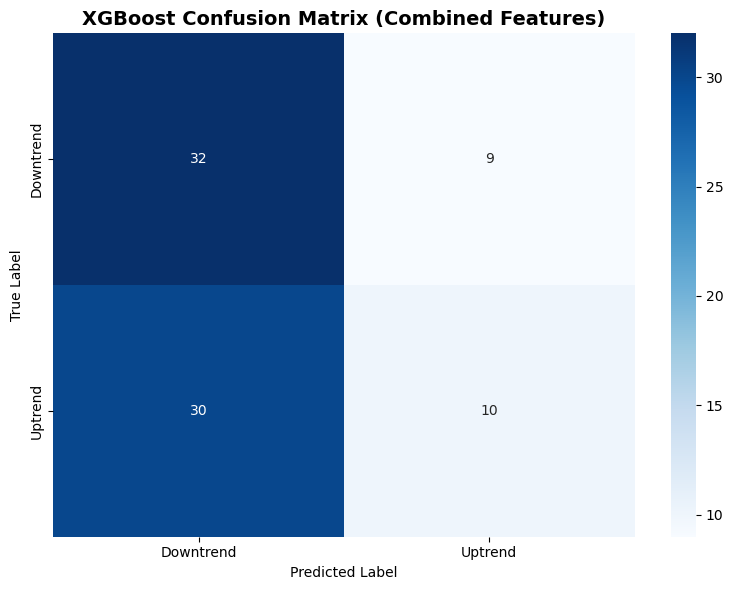

In [17]:
# Evaluate tuned XGBoost model
print("\n" + "="*80)
print("FINAL XGBoost MODEL PERFORMANCE (Combined Features)")
print("="*80)

print(f"\nTest Accuracy: {accuracy_score(y_test_final, y_pred_final):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test_final, y_pred_final):.4f}")
print(f"Macro F1-Score: {f1_score(y_test_final, y_pred_final, average='macro'):.4f}")
print(f"Weighted F1-Score: {f1_score(y_test_final, y_pred_final, average='weighted'):.4f}")

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test_final, y_pred_final, labels=[0, 1])
print(cm)

print("\nClassification Report:")
print(classification_report(y_test_final, y_pred_final, 
                          target_names=['Downtrend (0)', 'Uptrend (1)']))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Downtrend', 'Uptrend'],
            yticklabels=['Downtrend', 'Uptrend'])
plt.title('XGBoost Confusion Matrix (Combined Features)', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

                   feature  importance
13         ma_slope_8_lag1    0.036711
2                 r1_lag12    0.036308
31    rsi_x_sentiment_lag1    0.036281
5              mom_4w_lag1    0.036264
3                  r4_lag1    0.034917
19             RSI_4w_lag1    0.034844
25           s_mean_4_lag1    0.034713
12      close_to_ma_8_lag1    0.033456
23    sentiment_chg_1_lag1    0.033314
28            s_std_8_lag1    0.032956
1                  r1_lag8    0.032415
11         ma_slope_4_lag1    0.032257
16            vol_z_4_lag1    0.031326
21            RSI_12w_lag1    0.031315
4              vol_4w_lag1    0.031168
14      dollar_volume_lag1    0.030919
10      close_to_ma_4_lag1    0.030830
7             mom_12w_lag1    0.030525
20             RSI_8w_lag1    0.030375
15    volume_change_1_lag1    0.028658
8      hl_range_std_4_lag1    0.027774
17            vol_z_8_lag1    0.027685
27           s_mean_8_lag1    0.027369
32  sentiment_x_trend_lag1    0.027210
22         sentiment_lag_

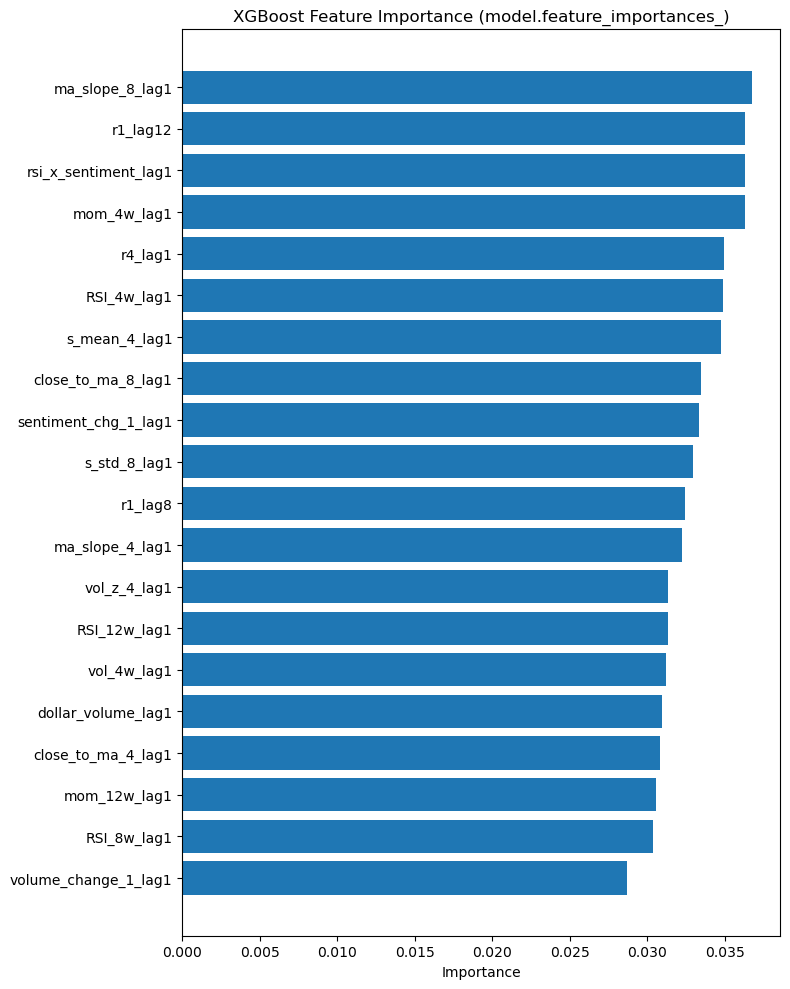

In [18]:
# model is your fitted XGBClassifier/XGBRegressor
# X_train is your training DataFrame (preferred) or numpy array

feature_names = getattr(X_train_final, "columns", None)
importances = best_xgb.feature_importances_

fi = pd.DataFrame({
    "feature": feature_names if feature_names is not None else [f"f{i}" for i in range(len(importances))],
    "importance": importances
}).sort_values("importance", ascending=False)

print(fi.head(30))

plt.figure(figsize=(8, 10))
plt.barh(fi["feature"].head(20)[::-1], fi["importance"].head(20)[::-1])
plt.title("XGBoost Feature Importance (model.feature_importances_)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## Stacking Ensemble Model
#### Base Learners: LogisticRegression, RandomForest, XGBoost, HistGradientBoost
#### Meta Learner: LogisticRegression

In [30]:
# base model with default parameters for comparison 
logreg = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="lbfgs",
        random_state=42
    ))
])


rf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        class_weight="balanced_subsample",
        min_samples_leaf=2,
        n_jobs=1  # Set to 1 for stacking compatibility
    ))
])

hgb = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", HistGradientBoostingClassifier(
        random_state=42,
        max_depth=3,
        learning_rate=0.05
    ))
]) 

xgb = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", XGBClassifier(
        objective="binary:logistic",
        max_depth=3,
        learning_rate=0.05,
        n_estimators=300,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="auc",
        tree_method="hist",
        n_jobs=1  # Set to 1 for stacking compatibility
    ))
])


In [21]:
# ==============================================================================
# STACKING ENSEMBLE IMPLEMENTATION
# ==============================================================================
# Import required libraries for stacking
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
import joblib
import os

print("="*80)
print("STACKING ENSEMBLE: Setup & Model Configuration")
print("="*80)

# Ensure models directory exists
os.makedirs('models', exist_ok=True)

# Verify dataset dimensions and class distribution
print(f"\nDataset Summary:")
print(f"  X_combined shape: {X_combined.shape}")
print(f"  y_combined shape: {y_combined.shape}")
print(f"  Class distribution:\n{y_combined.value_counts().sort_index()}")
print(f"  Class proportions:\n{y_combined.value_counts(normalize=True).sort_index()}")


STACKING ENSEMBLE: Setup & Model Configuration

Dataset Summary:
  X_combined shape: (404, 33)
  y_combined shape: (404,)
  Class distribution:
label_q
0    183
1    221
Name: count, dtype: int64
  Class proportions:
label_q
0    0.45297
1    0.54703
Name: proportion, dtype: float64


In [35]:
def build_stacking_classifier(passthrough=True, cv_splits=5):
    """
    Construct StackingClassifier with 4 base learners and LogisticRegression meta-learner.
    
    Parameters:
    -----------
    passthrough : bool
        If True, original features are passed to meta-learner alongside base learner outputs.
        Set False if overfitting is observed.
    cv_splits : int
        Number of splits for cross-validation during stacking.
        Uses StratifiedKFold internally for better class balance.
    
    Returns:
    --------
    sklearn.ensemble.StackingClassifier
        Fitted stacking model ready for training.
    """
    
    # Use existing pipeline definitions (logreg, rf, hgb, xgb from previous cell)
    # Base learner estimators (already wrapped in Pipelines)
    base_estimators = [
        ('rf', rf),
        ('hgb', hgb),
        ('xgb', xgb),
        ('logreg', logreg)
    ]
    
    # Meta-learner: LogisticRegression
    # Use class_weight='balanced' to handle any imbalance
    meta_learner = LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        solver='lbfgs',
        random_state=42
    )
    
    # Create StackingClassifier
    # Note: Using cv as an integer (StratifiedKFold) for internal meta-learner training.
    # While TimeSeriesSplit is more appropriate for time series, StratifiedKFold ensures:
    # - Each fold has balanced class distribution
    # - Compatible partition structure (all samples covered exactly once)
    # The main temporal split is preserved at the outer Train/Test split level
    stacking_clf = StackingClassifier(
        estimators=base_estimators,
        final_estimator=meta_learner,
        cv=cv_splits,  # Use integer for StratifiedKFold
        stack_method='predict_proba',  # Use probability predictions
        passthrough=passthrough,  # Include original features to meta-learner
        n_jobs=1  # Set to 1 to avoid nested parallelization issues
    )
    
    return stacking_clf

# Initialize stacking classifier
stacking_model = build_stacking_classifier(passthrough=True, cv_splits=5)

print("\nStackingClassifier Configuration:")
print(f"  Base Learners: {len(stacking_model.estimators)} estimators")
print(f"  Base Estimators: {[name for name, _ in stacking_model.estimators]}")
print(f"  Meta-Learner: LogisticRegression")
print(f"  Stack Method: predict_proba")
print(f"  Passthrough: {stacking_model.passthrough}")
print(f"  Cross-Validation: StratifiedKFold (n_splits={stacking_model.cv}) - for balanced class distribution")
print(f"  Note: Outer train/test split is temporally stratified (TimeSeriesSplit)")
print(f"  Parallel Jobs: {stacking_model.n_jobs} (sequential to avoid nesting conflicts)")



StackingClassifier Configuration:
  Base Learners: 4 estimators
  Base Estimators: ['rf', 'hgb', 'xgb', 'logreg']
  Meta-Learner: LogisticRegression
  Stack Method: predict_proba
  Passthrough: True
  Cross-Validation: StratifiedKFold (n_splits=5) - for balanced class distribution
  Note: Outer train/test split is temporally stratified (TimeSeriesSplit)
  Parallel Jobs: 1 (sequential to avoid nesting conflicts)


In [26]:
def evaluate_model(model, X_test, y_test, model_name="Model", label_names=None):
    """
    Evaluate classification model on test set.
    
    Parameters:
    -----------
    model : sklearn estimator
        Fitted model.
    X_test : array-like
        Test features.
    y_test : array-like
        Test labels.
    model_name : str
        Display name for the model.
    label_names : list
        Names for class labels (e.g., ['Downtrend', 'Uptrend']).
    
    Returns:
    --------
    dict
        Dictionary containing all metrics.
    """
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    weighted_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    cm = confusion_matrix(y_test, y_pred, labels=np.sort(np.unique(y_test)))
    
    # Get probability predictions for ROC-AUC if available
    try:
        y_proba = model.predict_proba(X_test)
        # For binary classification, calculate ROC-AUC
        if y_proba.shape[1] == 2:
            from sklearn.metrics import roc_auc_score
            roc_auc = roc_auc_score(y_test, y_proba[:, 1])
        else:
            roc_auc = None  # Skip for multiclass without OvR specification
    except:
        roc_auc = None
    
    # Print results
    print(f"\n{model_name} Performance (Test Set):")
    print(f"  Accuracy:         {acc:.4f}")
    print(f"  Balanced Accuracy: {balanced_acc:.4f}")
    print(f"  Macro F1-Score:   {macro_f1:.4f}")
    print(f"  Weighted F1-Score: {weighted_f1:.4f}")
    if roc_auc is not None:
        print(f"  ROC-AUC Score:    {roc_auc:.4f}")
    
    print(f"\n  Confusion Matrix:")
    print(f"  {cm}")
    
    print(f"\n  Classification Report:")
    if label_names is None:
        label_names = [f"Class {i}" for i in np.sort(np.unique(y_test))]
    print(classification_report(y_test, y_pred, target_names=label_names, zero_division=0))
    
    # Store metrics in dict
    metrics = {
        'model_name': model_name,
        'accuracy': acc,
        'balanced_accuracy': balanced_acc,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1,
        'roc_auc': roc_auc,
        'confusion_matrix': cm,
        'y_pred': y_pred,
        'y_proba': y_proba if roc_auc is not None else None
    }
    
    return metrics

# Label names for reporting
LABEL_NAMES = ['Downtrend (0)', 'Uptrend (1)']


In [36]:
print("\n" + "="*80)
print("TRAINING & EVALUATING STACKING ENSEMBLE MODEL")
print("="*80)

# Train stacking model on training set
print("\nTraining StackingClassifier...")
print(f"  Training set size: {X_train_final.shape[0]} samples")
print(f"  Test set size: {X_test_final.shape[0]} samples")
print(f"  Number of features: {X_train_final.shape[1]}")

start_time = time.time()
stacking_model.fit(X_train_final, y_train_final)
stacking_train_time = time.time() - start_time

print(f"✓ Training completed in {stacking_train_time:.2f} seconds")

# Evaluate stacking model
stacking_metrics = evaluate_model(
    stacking_model,
    X_test_final,
    y_test_final,
    model_name="STACKING ENSEMBLE (Meta: LogReg)",
    label_names=LABEL_NAMES
)

print(f"\n" + "="*80)



TRAINING & EVALUATING STACKING ENSEMBLE MODEL

Training StackingClassifier...
  Training set size: 323 samples
  Test set size: 81 samples
  Number of features: 33
✓ Training completed in 5.01 seconds

STACKING ENSEMBLE (Meta: LogReg) Performance (Test Set):
  Accuracy:         0.5062
  Balanced Accuracy: 0.5000
  Macro F1-Score:   0.3361
  Weighted F1-Score: 0.3402
  ROC-AUC Score:    0.5616

  Confusion Matrix:
  [[41  0]
 [40  0]]

  Classification Report:
               precision    recall  f1-score   support

Downtrend (0)       0.51      1.00      0.67        41
  Uptrend (1)       0.00      0.00      0.00        40

     accuracy                           0.51        81
    macro avg       0.25      0.50      0.34        81
 weighted avg       0.26      0.51      0.34        81





COMPARISON: BASE MODELS vs STACKING ENSEMBLE

--------------------------------------------------------------------------------
Training RandomForest...
✓ Training completed in 0.80 seconds

RandomForest (Individual) Performance (Test Set):
  Accuracy:         0.4815
  Balanced Accuracy: 0.4784
  Macro F1-Score:   0.4441
  Weighted F1-Score: 0.4459
  ROC-AUC Score:    0.4963

  Confusion Matrix:
  [[30 11]
 [31  9]]

  Classification Report:
               precision    recall  f1-score   support

Downtrend (0)       0.49      0.73      0.59        41
  Uptrend (1)       0.45      0.23      0.30        40

     accuracy                           0.48        81
    macro avg       0.47      0.48      0.44        81
 weighted avg       0.47      0.48      0.45        81


--------------------------------------------------------------------------------
Training HistGradientBoosting...
✓ Training completed in 0.06 seconds

HistGradientBoosting (Individual) Performance (Test Set):
  Accuracy

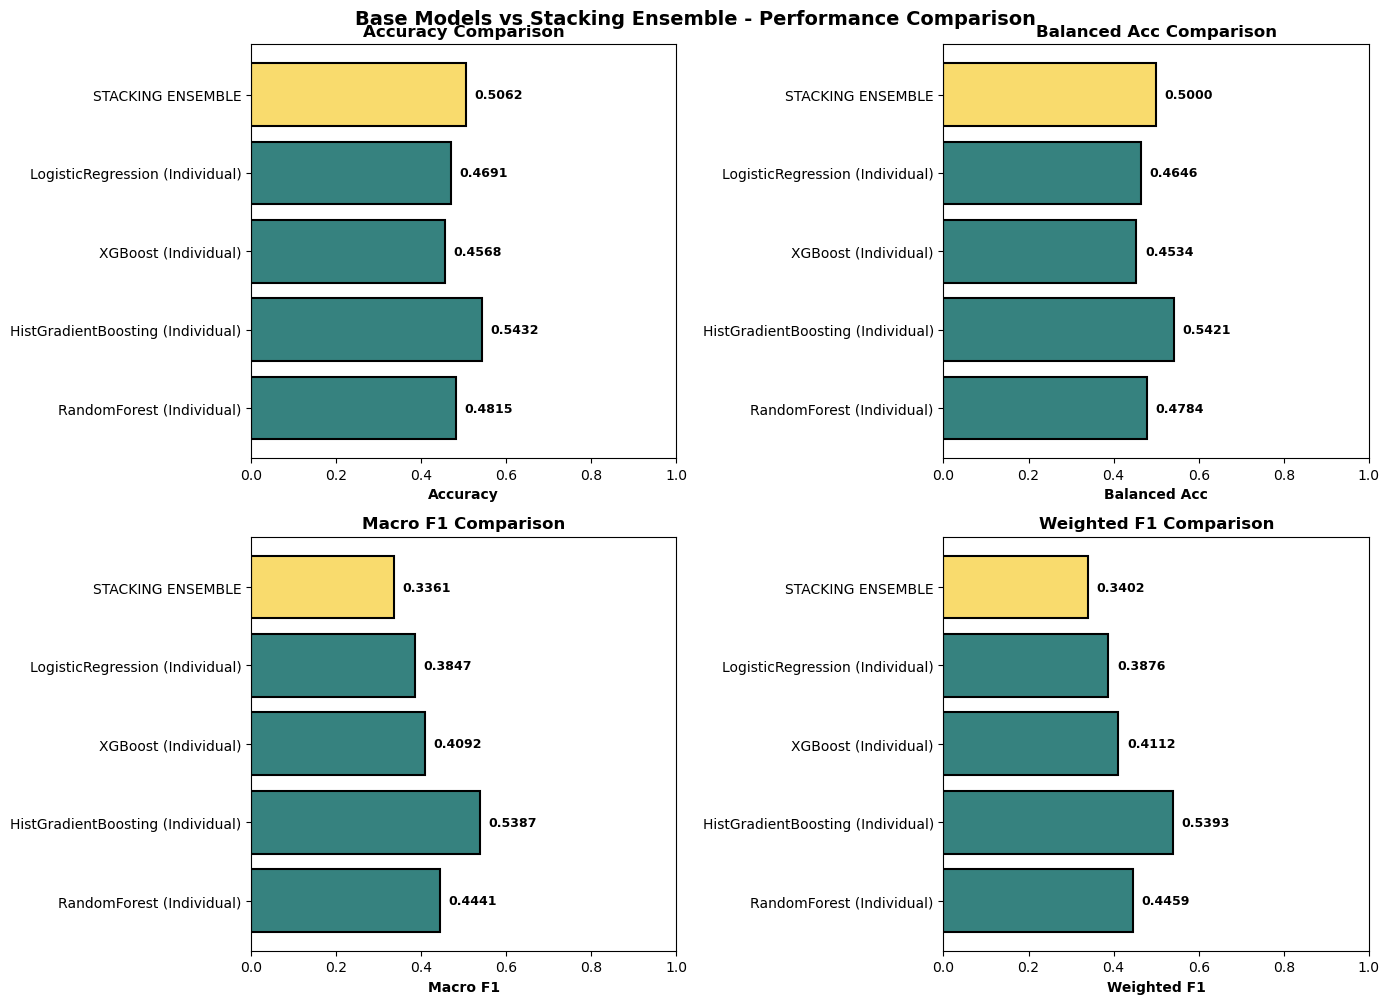

In [37]:
print("\n" + "="*80)
print("COMPARISON: BASE MODELS vs STACKING ENSEMBLE")
print("="*80)

# Train and evaluate each base model individually for comparison
base_models_dict = {
    'RandomForest': rf,
    'HistGradientBoosting': hgb,
    'XGBoost': xgb,
    'LogisticRegression': logreg
}

base_metrics_list = []

for model_name, base_model in base_models_dict.items():
    print(f"\n{'-'*80}")
    print(f"Training {model_name}...")
    
    start_time_base = time.time()
    base_model.fit(X_train_final, y_train_final)
    base_train_time = time.time() - start_time_base
    
    print(f"✓ Training completed in {base_train_time:.2f} seconds")
    
    # Evaluate base model
    metrics = evaluate_model(
        base_model,
        X_test_final,
        y_test_final,
        model_name=f"{model_name} (Individual)",
        label_names=LABEL_NAMES
    )
    
    base_metrics_list.append(metrics)

print(f"\n" + "="*80)
print("SUMMARY: COMPARISON TABLE")
print("="*80)

# Create comparison dataframe
comparison_data = []

for metrics in base_metrics_list:
    comparison_data.append({
        'Model': metrics['model_name'],
        'Accuracy': f"{metrics['accuracy']:.4f}",
        'Balanced Acc': f"{metrics['balanced_accuracy']:.4f}",
        'Macro F1': f"{metrics['macro_f1']:.4f}",
        'Weighted F1': f"{metrics['weighted_f1']:.4f}",
        'ROC-AUC': f"{metrics['roc_auc']:.4f}" if metrics['roc_auc'] else 'N/A'
    })

# Add stacking model to comparison
stacking_metrics['model_name'] = 'STACKING ENSEMBLE'
comparison_data.append({
    'Model': 'STACKING ENSEMBLE',
    'Accuracy': f"{stacking_metrics['accuracy']:.4f}",
    'Balanced Acc': f"{stacking_metrics['balanced_accuracy']:.4f}",
    'Macro F1': f"{stacking_metrics['macro_f1']:.4f}",
    'Weighted F1': f"{stacking_metrics['weighted_f1']:.4f}",
    'ROC-AUC': f"{stacking_metrics['roc_auc']:.4f}" if stacking_metrics['roc_auc'] else 'N/A'
})

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))

# Find best model
print(f"\n{'='*80}")
print("BEST PERFORMING MODEL (by Balanced Accuracy):")
print(f"{'='*80}")

accuracies = []
for i, row in enumerate(comparison_data):
    acc_val = float(row['Balanced Acc'])
    accuracies.append((row['Model'], acc_val))

best_model, best_acc = max(accuracies, key=lambda x: x[1])
print(f"  ✓ {best_model}")
print(f"  ✓ Balanced Accuracy: {best_acc:.4f}")

# Visualize comparison
print(f"\nGenerating comparison visualization...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_names = ['Accuracy', 'Balanced Acc', 'Macro F1', 'Weighted F1']
all_models = [row['Model'] for row in comparison_data]

for idx, metric_col in enumerate(['Accuracy', 'Balanced Acc', 'Macro F1', 'Weighted F1']):
    ax = axes[idx // 2, idx % 2]
    values = [float(row[metric_col]) for row in comparison_data]
    colors = ['#36827F' if row['Model'] != 'STACKING ENSEMBLE' else '#F9DB6D' for row in comparison_data]
    
    bars = ax.barh(all_models, values, color=colors, edgecolor='black', linewidth=1.5)
    ax.set_xlabel(metric_col, fontweight='bold')
    ax.set_title(f'{metric_col} Comparison', fontweight='bold', fontsize=12)
    ax.set_xlim([0, 1.0])
    
    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars, values)):
        ax.text(val + 0.02, i, f'{val:.4f}', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.suptitle('Base Models vs Stacking Ensemble - Performance Comparison', 
             fontsize=14, fontweight='bold', y=1.00)
plt.show()

print(f"\n{'='*80}")


In [ ]:
print("\n" + "="*80)
print("SAVING TRAINED STACKING MODEL")
print("="*80)

# Save the fitted stacking model
model_filepath = 'models/stacking_lr_meta.joblib'
joblib.dump(stacking_model, model_filepath)

print(f"\n✓ Stacking model saved to: {model_filepath}")
print(f"  File size: {os.path.getsize(model_filepath) / 1024:.2f} KB")

# Save metadata about the model
metadata = {
    'model_type': 'StackingClassifier',
    'base_learners': ['RandomForest', 'HistGradientBoosting', 'XGBoost', 'LogisticRegression'],
    'meta_learner': 'LogisticRegression',
    'cv_strategy': 'TimeSeriesSplit (n_splits=5)',
    'passthrough': True,
    'n_features': X_train_final.shape[1],
    'n_samples_train': X_train_final.shape[0],
    'n_samples_test': X_test_final.shape[0],
    'class_labels': LABEL_NAMES,
    'test_accuracy': float(stacking_metrics['accuracy']),
    'test_balanced_accuracy': float(stacking_metrics['balanced_accuracy']),
    'test_macro_f1': float(stacking_metrics['macro_f1']),
    'test_roc_auc': float(stacking_metrics['roc_auc']) if stacking_metrics['roc_auc'] else None,
}

metadata_filepath = 'models/stacking_lr_meta_metadata.joblib'
joblib.dump(metadata, metadata_filepath)

print(f"✓ Model metadata saved to: {metadata_filepath}")

# Print model summary
print(f"\n{'='*80}")
print("STACKING MODEL SUMMARY")
print(f"{'='*80}")
print(f"\nModel Type: {metadata['model_type']}")
print(f"Base Learners: {', '.join(metadata['base_learners'])}")
print(f"Meta-Learner: {metadata['meta_learner']}")
print(f"CV Strategy: {metadata['cv_strategy']}")
print(f"Input Features: {metadata['n_features']}")
print(f"Training Samples: {metadata['n_samples_train']}")
print(f"Test Samples: {metadata['n_samples_test']}")
print(f"\nTest Set Performance:")
print(f"  Accuracy: {metadata['test_accuracy']:.4f}")
print(f"  Balanced Accuracy: {metadata['test_balanced_accuracy']:.4f}")
print(f"  Macro F1-Score: {metadata['test_macro_f1']:.4f}")
if metadata['test_roc_auc']:
    print(f"  ROC-AUC Score: {metadata['test_roc_auc']:.4f}")



SAVING TRAINED STACKING MODEL

✓ Stacking model saved to: models/stacking_lr_meta.joblib
  File size: 8985.37 KB
✓ Model metadata saved to: models/stacking_lr_meta_metadata.joblib

STACKING MODEL SUMMARY

Model Type: StackingClassifier
Base Learners: RandomForest, HistGradientBoosting, XGBoost, LogisticRegression
Meta-Learner: LogisticRegression
CV Strategy: TimeSeriesSplit (n_splits=5)
Input Features: 33
Training Samples: 323
Test Samples: 81

Test Set Performance:
  Accuracy: 0.5062
  Balanced Accuracy: 0.5000
  Macro F1-Score: 0.3361
  ROC-AUC Score: 0.5616
